# Background

We are a small startup focusing mainly on providing machine learning solutions in the European banking market. We work on a variety of problems including fraud detection, sentiment classification and customer intention prediction and classification.

We are interested in developing a robust machine learning system that leverages information coming from call center data.

Ultimately, we are looking for ways to improve the success rate for calls made to customers for any product that our clients offer. Towards this goal we are working on designing an ever evolving machine learning product that offers high success outcomes while offering interpretability for our clients to make informed decisions.

## Data Description

The data comes from direct marketing efforts of a European banking institution. The marketing campaign involves making a phone call to a customer, often multiple times to ensure a product subscription, in this case a term deposit. Term deposits are usually short-term deposits with maturities ranging from one month to a few years. The customer must understand when buying a term deposit that they can withdraw their funds only after the term ends. All customer information that might reveal personal information is removed due to privacy concerns.

Attributes:

age : age of customer (numeric)

job : type of job (categorical)

marital : marital status (categorical)

education (categorical)

default: has credit in default? (binary)

balance: average yearly balance, in euros (numeric)

housing: has a housing loan? (binary)

loan: has personal loan? (binary)

contact: contact communication type (categorical)

day: last contact day of the month (numeric)

month: last contact month of year (categorical)

duration: last contact duration, in seconds (numeric)

campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

Output (desired target):

y - has the client subscribed to a term deposit? (binary)

# EDA

## Data Loading

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
import missingno as msno
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix



pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

In [76]:
file_path = 'term-deposit-marketing-2020.csv'
df = pd.read_csv(file_path)

In [77]:
display(df.head())
display(df.tail())

print('=== SHAPE ===')
print(df.shape,'\n')
print('=== DTYPES ===')
print(df.dtypes, '\n')
print('=== NULLS ===')
print(df.isnull().sum(), '\n')
print('=== DUPES ===')
print(df.duplicated().sum(), '\n')
print('=== DESCRIBE ===')
display(df.describe(include='all'))

df.info()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no
39999,38,technician,married,secondary,no,1442,yes,no,cellular,3,jun,113,1,no


=== SHAPE ===
(40000, 14) 

=== DTYPES ===
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
y            object
dtype: object 

=== NULLS ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64 

=== DUPES ===
0 

=== DESCRIBE ===


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
count,40000.0000,40000,40000,40000,40000,40000.0000,40000,40000,40000,40000.0000,40000,40000.0000,40000.0000,40000
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,11,NaN,NaN,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,no
freq,NaN,9383,24386,20993,39191,NaN,24031,33070,24914,NaN,13532,NaN,NaN,37104
mean,40.5446,NaN,NaN,NaN,NaN,1274.2776,NaN,NaN,NaN,16.0172,NaN,254.8243,2.8822,NaN
std,9.6418,NaN,NaN,NaN,NaN,2903.7697,NaN,NaN,NaN,8.2781,NaN,259.3665,3.2391,NaN
min,19.0000,NaN,NaN,NaN,NaN,-8019.0000,NaN,NaN,NaN,1.0000,NaN,0.0000,1.0000,NaN
25%,33.0000,NaN,NaN,NaN,NaN,54.0000,NaN,NaN,NaN,8.0000,NaN,100.0000,1.0000,NaN
50%,39.0000,NaN,NaN,NaN,NaN,407.0000,NaN,NaN,NaN,17.0000,NaN,175.0000,2.0000,NaN
75%,48.0000,NaN,NaN,NaN,NaN,1319.0000,NaN,NaN,NaN,21.0000,NaN,313.0000,3.0000,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


According to the above inspections of the dataset, 37104 respondents responded with no, indicating a 92.8% decline rate (or a 7.2% success rate)

## Data Quality Checks

Missing Values
Series([], )


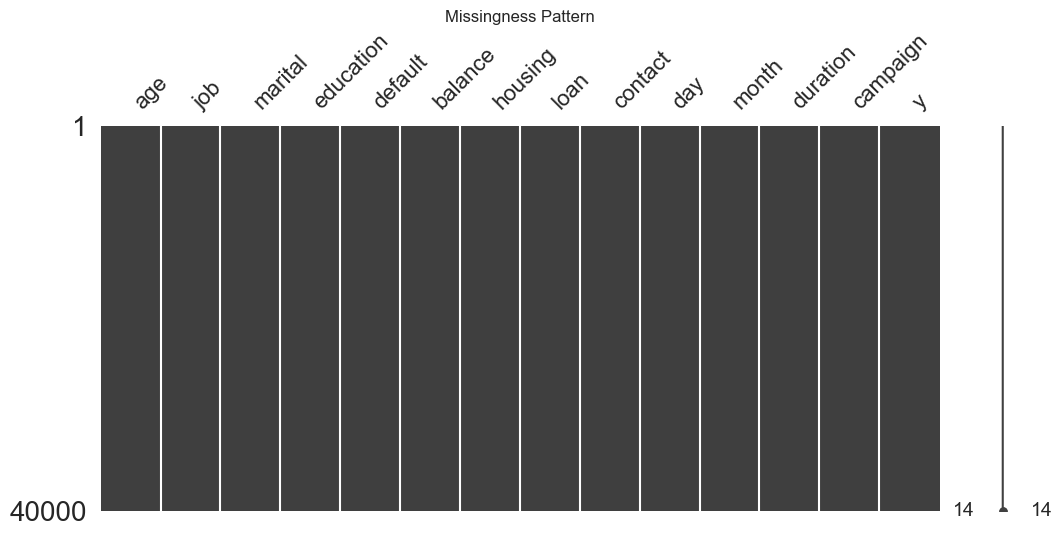

In [78]:
print("Missing Values")
miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False) 
miss = miss[miss > 0].rename('missing_%') 
print(miss.to_string()) 

# Visualise missingness pattern
msno.matrix(df, figsize=(12, 5)) 
plt.title('Missingness Pattern') 
plt.show()


## EDA Proper

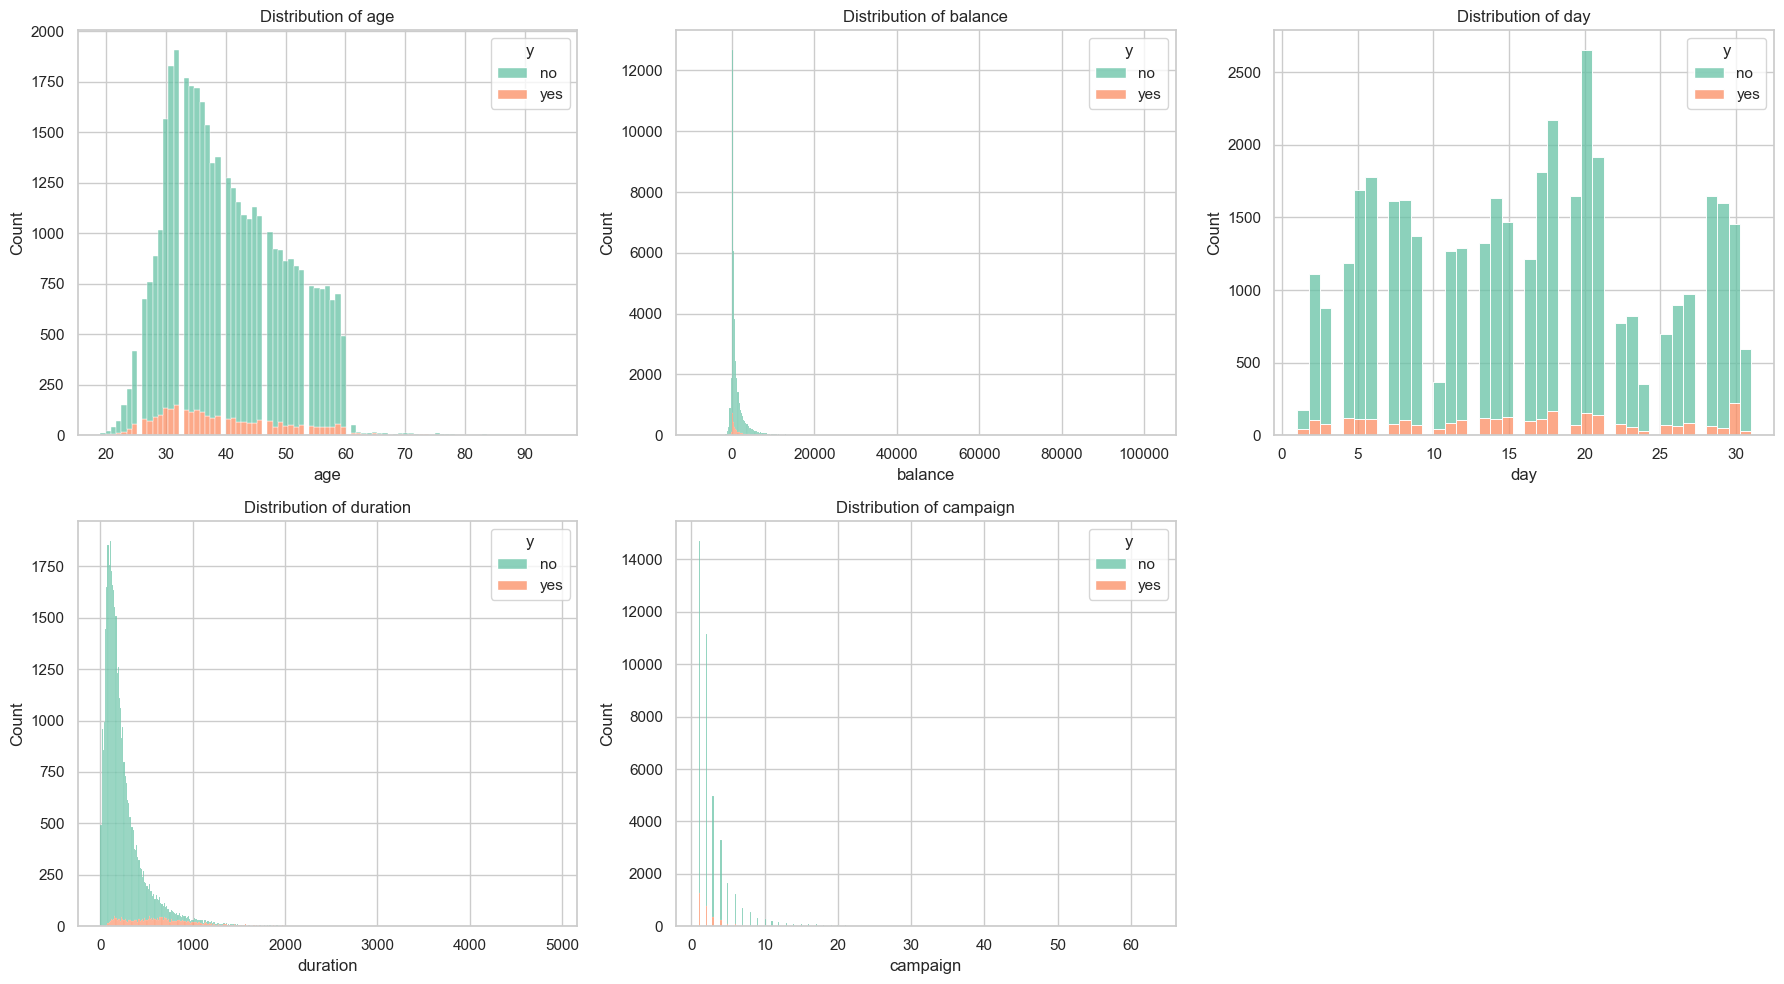

In [79]:
# Numerical features
num_features = ['age', 'balance', 'day', 'duration', 'campaign']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(num_features):
    sns.histplot(
        data=df,
        x=feature,
        hue='y',
        multiple='stack',      # or 'dodge'
        kde=False,
        ax=axes[idx]
    )
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [80]:
for col in ['age', 'balance', 'day', 'duration', 'campaign']:
    print(f"\n--- {col} ---")
    print(df[col].describe())
    print(f"Skewness : {df[col].skew():.3f}")
    print(f"Kurtosis : {df[col].kurtosis():.3f}")
    print(f"CV : {df[col].std()/df[col].mean()*100:.1f}%")


--- age ---
count   40000.0000
mean       40.5446
std         9.6418
min        19.0000
25%        33.0000
50%        39.0000
75%        48.0000
max        95.0000
Name: age, dtype: float64
Skewness : 0.436
Kurtosis : -0.504
CV : 23.8%

--- balance ---
count    40000.0000
mean      1274.2776
std       2903.7697
min      -8019.0000
25%         54.0000
50%        407.0000
75%       1319.0000
max     102127.0000
Name: balance, dtype: float64
Skewness : 8.259
Kurtosis : 141.833
CV : 227.9%

--- day ---
count   40000.0000
mean       16.0172
std         8.2781
min         1.0000
25%         8.0000
50%        17.0000
75%        21.0000
max        31.0000
Name: day, dtype: float64
Skewness : 0.068
Kurtosis : -1.053
CV : 51.7%

--- duration ---
count   40000.0000
mean      254.8243
std       259.3665
min         0.0000
25%       100.0000
50%       175.0000
75%       313.0000
max      4918.0000
Name: duration, dtype: float64
Skewness : 3.165
Kurtosis : 18.190
CV : 101.8%

--- campaign ---
count

Age is roughly symmetric with a slight right skew (0.436), close to normal in shape.
CV of 23.8% shows moderate spread relative to the mean.

Balance is extremely right-skewed (skew 8.26, kurtosis 141.8) with a CV of 228%.
Mean is not representative here, driven by outliers up to 102k.
Negative balances (min -8019) also present, likely overdrafts.

Day is nearly symmetric (skew 0.068) and flatter than normal (kurtosis -1.05).
Consistent with contact day being roughly uniform across the month.

Duration is heavily right-skewed (skew 3.17, kurtosis 18.19) with std exceeding the mean (CV 102%).
Most calls are short but a long tail stretches to about 82 minutes (4918s).
Min of 0 seconds also worth flagging, possibly non-contacts or a logging artifact.

Campaign is the most skewed of the numeric features (skew 4.73, kurtosis 36.2, CV 112%).
Most customers contacted 1-3 times, but a handful reached up to 63 contacts, likely outliers worth capping or investigating.

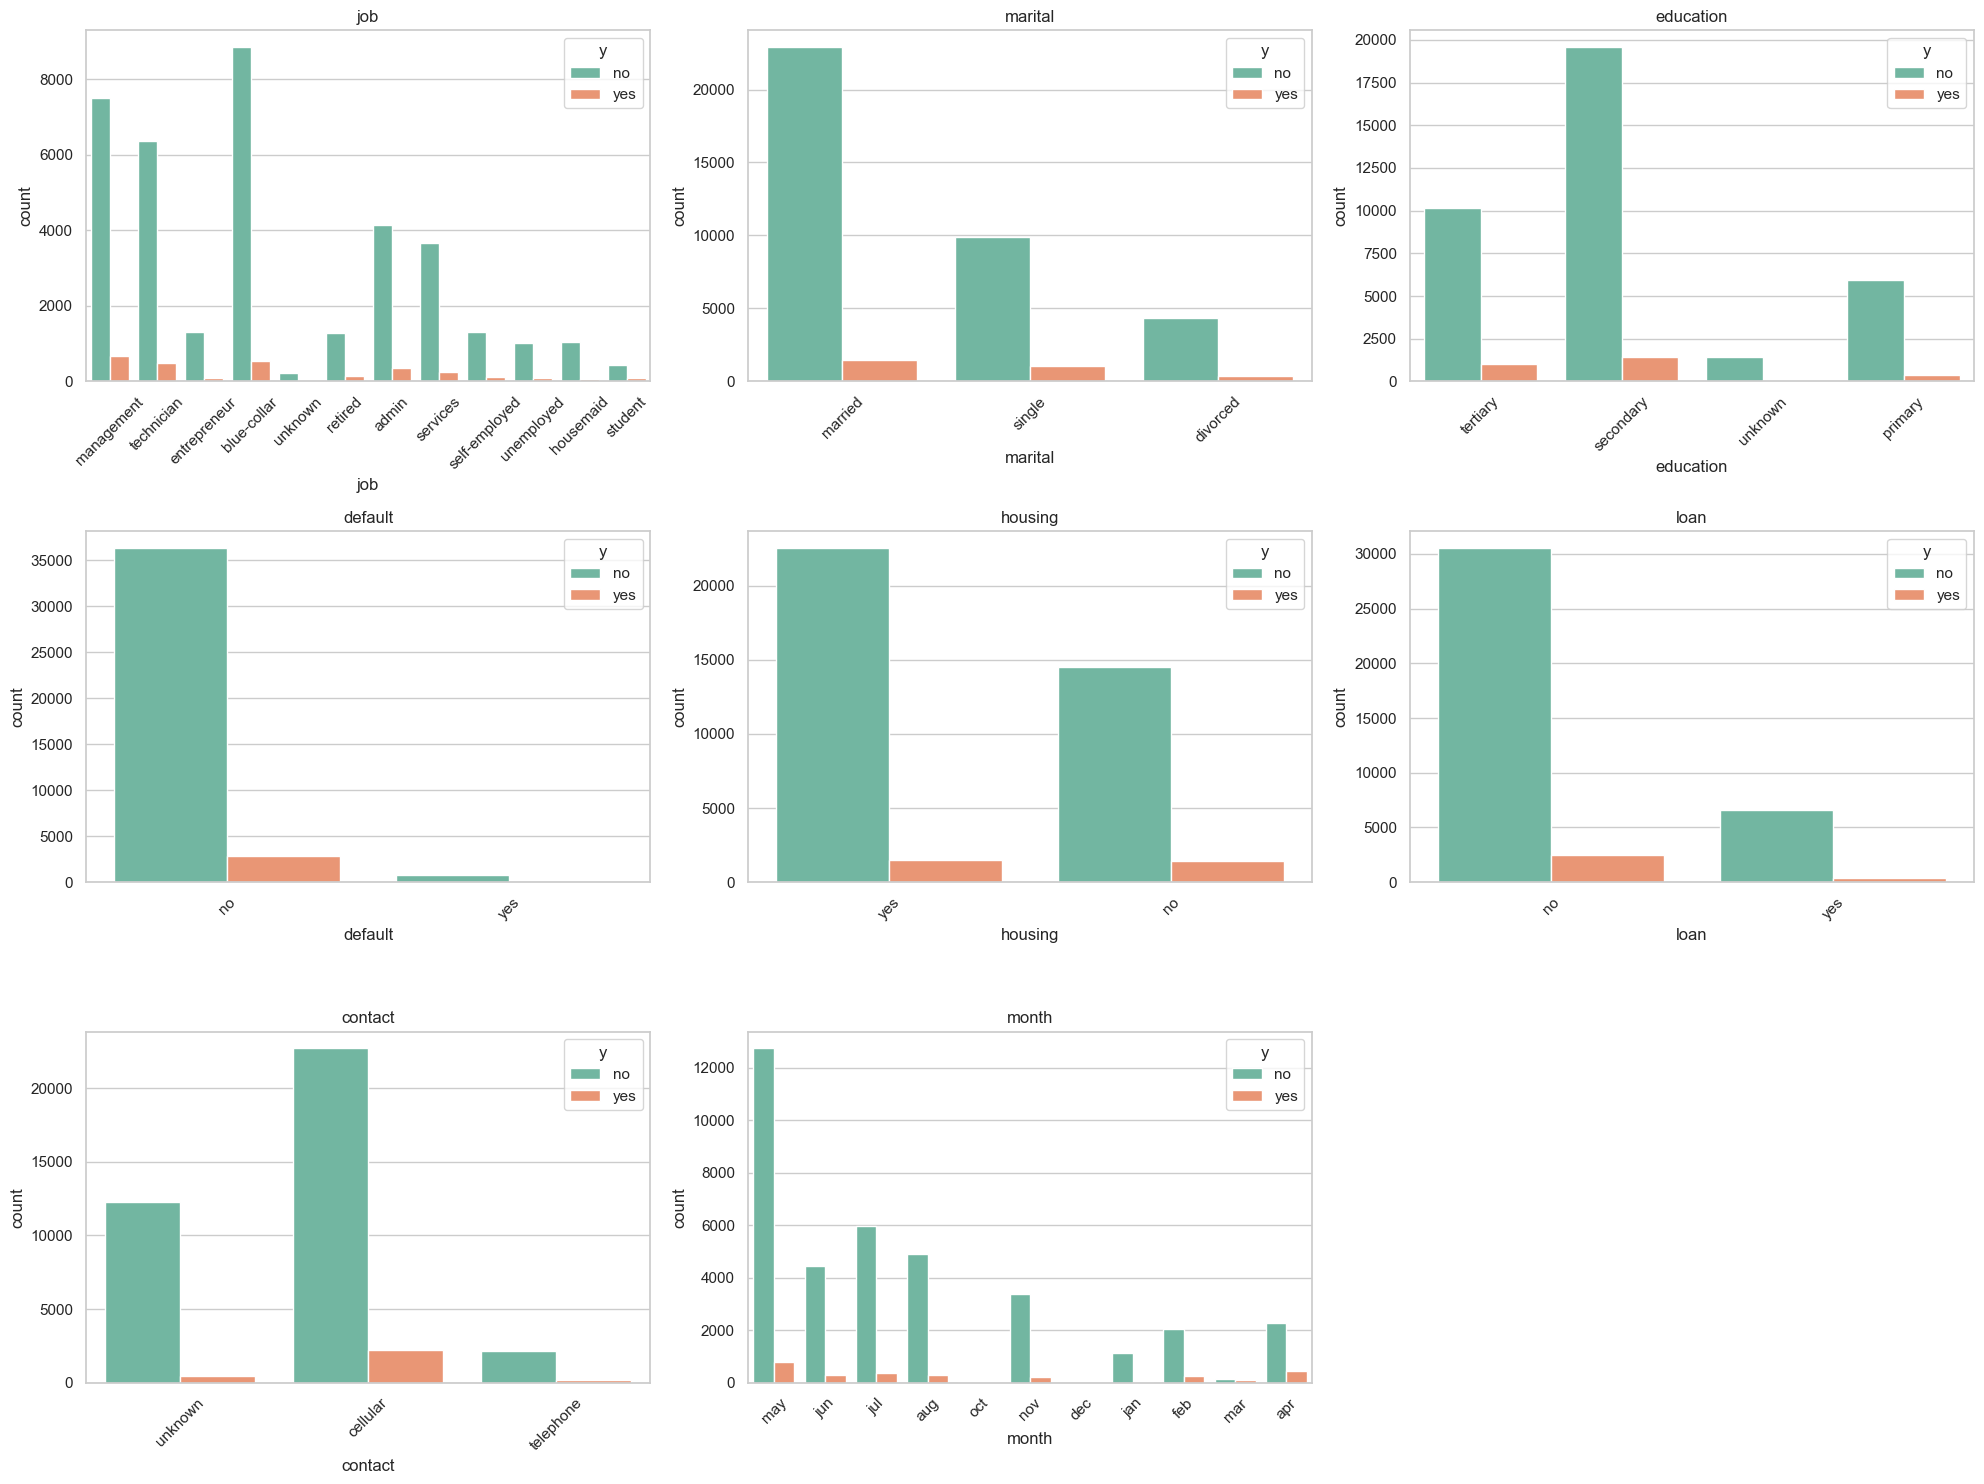

In [81]:
cat_features = [
    'job', 'marital', 'education',
    'default', 'housing', 'loan',
    'contact', 'month'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.ravel()

for idx, feature in enumerate(cat_features):
    sns.countplot(
        data=df,
        x=feature,
        hue='y',
        ax=axes[idx]
    )
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_title(feature)

# Remove the extra subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Cellular is the largest contact type by count for both yes and no responses.

Customers marked "yes" for default show almost no "yes" responses to the campaign.
There's a larger count of people with no loans.

Blue-collar has the highest overall call count, though its yes rate is similar to management, technician, admin, etc.

Housemaid, student, self-employed, retired, and entrepreneur show more "no" responses overall, but this should be checked as a ratio, not raw count.

In [82]:
df_encoded = df.copy()

# Binary encoding (Yes/No -> 1/0)
binary_cols = ['default', 'housing', 'loan', 'y']

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})

# Ordinal encoding (education)
education_order = {
    'primary': 0,
    'secondary': 1,
    'tertiary': 2,
    'unknown': 3
}

df_encoded['education'] = df_encoded['education'].map(education_order)

# One-hot encode nominal variables
nominal_cols = ['job', 'marital', 'contact', 'month']

df_encoded = pd.get_dummies(
    df_encoded,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)

df_encoded.head()

,age,education,default,balance,housing,loan,day,duration,campaign,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct
0,58,2,0,2143,1,0,5,261,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0
1,44,1,0,29,1,0,5,151,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,33,1,0,2,1,1,5,76,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0
3,47,3,0,1506,1,0,5,92,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0
4,33,3,0,1,0,0,5,198,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [83]:
# --- Feature engineering, done once on df_encoded before any layer-specific split ---

# Age bins — captures non-linear age effects a linear model can't see in raw age
df_encoded['age_bin'] = pd.cut(
    df_encoded['age'],
    bins=[0, 30, 45, 60, 100],
    labels=['young', 'adult', 'mid', 'senior']
)
df_encoded = pd.get_dummies(df_encoded, columns=['age_bin'], drop_first=True, dtype=int)

# Balance sign flags — separates "has debt/overdraft" from "has none" from "has savings"
df_encoded['balance_negative'] = (df_encoded['balance'] < 0).astype(int)
df_encoded['balance_zero'] = (df_encoded['balance'] == 0).astype(int)

# Combined debt flag — captures whether someone carries any loan obligation at all
df_encoded['has_any_debt'] = ((df_encoded['housing'] == 1) | (df_encoded['loan'] == 1)).astype(int)

df_encoded.head()

,age,education,default,balance,housing,loan,day,duration,campaign,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,age_bin_adult,age_bin_mid,age_bin_senior,balance_negative,balance_zero,has_any_debt
0,58,2,0,2143,1,0,5,261,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1
1,44,1,0,29,1,0,5,151,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1
2,33,1,0,2,1,1,5,76,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1
3,47,3,0,1506,1,0,5,92,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1
4,33,3,0,1,0,0,5,198,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [84]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_features = ['age', 'balance', 'day', 'duration', 'campaign', 'education', 'default', 'housing', 'loan', 'y']

# corr on the interpretable subset only — skip one-hot dummies, they clutter the heatmap
corr = df_encoded[vif_features].corr(method='pearson')
display(corr.style.background_gradient(cmap='coolwarm'))

X = df_encoded[vif_features]
X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif['feature'] = X_const.columns
vif['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif)

,age,balance,day,duration,campaign,education,default,housing,loan,y
age,1.000000,0.081517,-0.011689,-0.036270,0.016204,-0.091083,-0.014857,-0.179606,0.000041,-0.020273
balance,0.081517,1.000000,0.011662,0.014072,-0.008137,0.066592,-0.070069,-0.049946,-0.080596,0.030232
day,-0.011689,0.011662,1.000000,-0.032983,0.165429,0.036206,0.006287,-0.050622,0.005838,-0.006420
duration,-0.036270,0.014072,-0.032983,1.000000,-0.088387,0.001828,-0.008597,0.022455,-0.003952,0.461169
campaign,0.016204,-0.008137,0.165429,-0.088387,1.000000,0.016562,0.012135,-0.054823,0.000582,-0.040350
education,-0.091083,0.066592,0.036206,0.001828,0.016562,1.000000,-0.006647,-0.083699,-0.043702,0.037585
default,-0.014857,-0.070069,0.006287,-0.008597,0.012135,-0.006647,1.000000,-0.019229,0.075006,-0.006559
housing,-0.179606,-0.049946,-0.050622,0.022455,-0.054823,-0.083699,-0.019229,1.000000,0.004266,-0.054336
loan,0.000041,-0.080596,0.005838,-0.003952,0.000582,-0.043702,0.075006,0.004266,1.000000,-0.031029
y,-0.020273,0.030232,-0.006420,0.461169,-0.040350,0.037585,-0.006559,-0.054336,-0.031029,1.000000


      feature     VIF
0       const 33.9957
1         age  1.0547
2     balance  1.0245
3         day  1.0319
4    duration  1.2827
5    campaign  1.0380
6   education  1.0277
7     default  1.0107
8     housing  1.0557
9        loan  1.0139
10          y  1.2806


No high collinearity or correlation found.

# Analysis

In [85]:
df['y'].value_counts(normalize=True)

#This checks y's balance

y
no    0.9276
yes   0.0724
Name: proportion, dtype: float64

## Balance Checking and Fixing

In [86]:
for col in ['age', 'balance']:
    stat, p = stats.shapiro(df[col].dropna()[:5000])
    print(f'{col}: W={stat:.3f} p={p:.4f}')

#normality checks

age: W=0.972 p=0.0000
balance: W=0.386 p=0.0000


Neither age nor balance are normal, and therefore a standard t-test is inapplicable

In [87]:
for col in ['age', 'balance']:
    yes = df[df['y']=='yes'][col].dropna()
    no = df[df['y']=='no'][col].dropna()
    u, p = stats.mannwhitneyu(yes, no)
    print(f'{col}: U={u:.1f} p={p:.4f}')

#num x cat

age: U=49798906.0 p=0.0000
balance: U=60623414.5 p=0.0000


Both age and balance seem to be differ across yes and no y outputs, however significance and magnitude are yet to be calculated.

In [88]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact']
for col in cat_cols:
    ct = pd.crosstab(df[col], df['y'])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    print(f'{col}: chi2={chi2:.2f} p={p:.4f} CramV={v:.3f} min_expected={expected.min():.1f}')

    #cat x cat

job: chi2=149.75 p=0.0000 CramV=0.061 min_expected=17.0
marital: chi2=135.90 p=0.0000 CramV=0.058 min_expected=342.1
education: chi2=96.67 p=0.0000 CramV=0.049 min_expected=110.8
default: chi2=1.55 p=0.2137 CramV=0.006 min_expected=58.6
housing: chi2=117.67 p=0.0000 CramV=0.054 min_expected=1156.2
loan: chi2=38.20 p=0.0000 CramV=0.031 min_expected=501.7
contact: chi2=323.01 p=0.0000 CramV=0.090 min_expected=168.0


Default showed no relationship regarding whether or not a respondent responds yes or no.
The rest of the categories indicate a relationship, but weak given their overall low CramV scores of less than 0.1

In [89]:
layer1_features = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'age', 'balance']

In [90]:
layer1_numeric_binary = ['age', 'balance', 'education', 'housing', 'loan']
layer1_dummy_prefixes = ['job_', 'marital_', 'contact_']

cols = layer1_numeric_binary + [c for c in df_encoded.columns if any(c.startswith(p) for p in layer1_dummy_prefixes)]
df_layer1 = df_encoded[cols + ['y']].copy()

In [91]:
df_layer1.columns.tolist()

['age',
 'balance',
 'education',
 'housing',
 'loan',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_married',
 'marital_single',
 'contact_telephone',
 'contact_unknown',
 'y']

In [92]:
#Fixing balance's skewness using Yeo-Johnson transformation

from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df_layer1['balance_yj'] = pt.fit_transform(df_layer1[['balance']])
print(df_layer1['balance_yj'].skew())

1.058649182360973


## Stratification

In [93]:
X = df_layer1.drop(columns=['y', 'balance'])
y = df_layer1['y'].map({'yes': 1, 'no': 0}) if df_layer1['y'].dtype == object else df_layer1['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

y
0   0.9276
1   0.0724
Name: proportion, dtype: float64
y
0   0.9276
1   0.0724
Name: proportion, dtype: float64


## Model Testing

In [94]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f'--- {name} ---')
    print(classification_report(y_test, preds))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.96      0.56      0.70      7421
           1       0.11      0.67      0.18       579

    accuracy                           0.56      8000
   macro avg       0.53      0.61      0.44      8000
weighted avg       0.89      0.56      0.67      8000

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7421
           1       0.12      0.13      0.13       579

    accuracy                           0.87      8000
   macro avg       0.53      0.53      0.53      8000
weighted avg       0.87      0.87      0.87      8000

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      7421
           1       0.24      0.07      0.10       579

    accuracy                           0.92      8000
   macro avg       0.59      0.52      0.53      8000
we

Summary
| Model | Precision (yes) | Recall (yes) | F1 (yes) |
|---|---|---|---|
| Logistic Regression | 0.11 | 0.67 | 0.18 |
| Decision Tree | 0.12 | 0.13 | 0.13 |
| Random Forest | 0.24 | 0.07 | 0.10 |
| XGBoost | 0.11 | 0.41 | 0.18 |

Random forest resulted as most precise.
Logistic regression correctly identified 67 out of 100 subscribers (correctly identifying the "yes" target)
Logistic regression and XGBoost both come out as best for F1 (joined test of precision and recall)


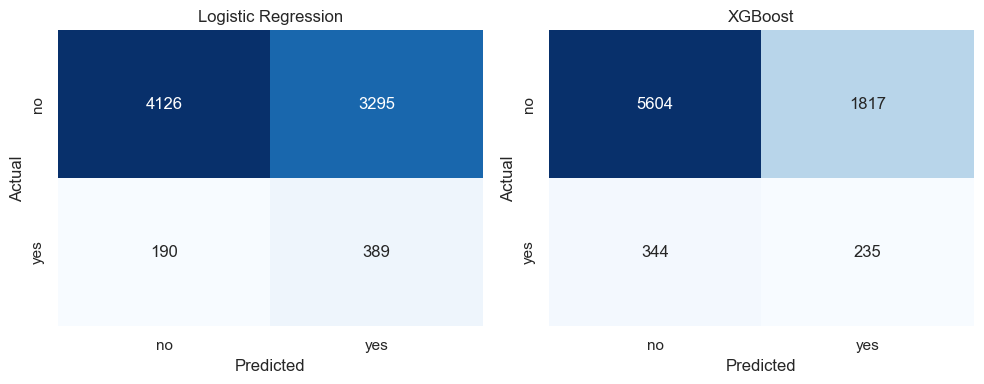

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, name in zip(axes, ['Logistic Regression', 'XGBoost']):
    cm = confusion_matrix(y_test, models[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['no', 'yes'], yticklabels=['no', 'yes'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# First Layer - Model Tuning

## Hyper Optimization

### Logistic Regression

In [96]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from sklearn.model_selection import cross_val_score

space_lr = {
    'C': hp.loguniform('C', np.log(1e-3), np.log(1e2)),
    'penalty': hp.choice('penalty', ['l1', 'l2']),
}

def obj_lr(p):
    m = LogisticRegression(**p, solver='liblinear', class_weight='balanced',
    max_iter=1000, random_state=42)
    f1 = cross_val_score(m, X_train, y_train, cv=5, scoring='f1', n_jobs=-1).mean()
    return {'loss': -f1, 'status': STATUS_OK}

best_lr = space_eval(space_lr, fmin(obj_lr, space_lr, tpe.suggest,
    max_evals=40, trials=Trials(),
    rstate=np.random.default_rng(42)))
print(best_lr)

lr_tuned = LogisticRegression(**best_lr, solver='liblinear', class_weight='balanced',
    max_iter=1000, random_state=42).fit(X_train, y_train)
print(classification_report(y_test, lr_tuned.predict(X_test), digits=3))

100%|██████████| 40/40 [00:34<00:00,  1.15trial/s, best loss: -0.17790400419547886]
{'C': 0.0032765011949658185, 'penalty': 'l2'}
              precision    recall  f1-score   support

           0      0.956     0.571     0.715      7421
           1      0.108     0.667     0.186       579

    accuracy                          0.578      8000
   macro avg      0.532     0.619     0.450      8000
weighted avg      0.895     0.578     0.676      8000



### XGBoost

In [97]:
space_xgb = {
    'max_depth': hp.choice('max_depth', [3, 4, 5, 6, 7]),
    'learning_rate': hp.loguniform('learning_rate', np.log(1e-3), np.log(1)),
    'n_estimators': hp.choice('n_estimators', [100, 200, 300]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0)
}

scale_pos_weight = (y_train==0).sum()/(y_train==1).sum()

def obj_xgb(p):
    m = XGBClassifier(**p, scale_pos_weight=scale_pos_weight, random_state=42)
    f1 = cross_val_score(m, X_train, y_train, cv=5, scoring='f1', n_jobs=-1).mean()
    return {'loss': -f1, 'status': STATUS_OK}

best_xgb = space_eval(space_xgb, fmin(obj_xgb, space_xgb, tpe.suggest,
    max_evals=40, trials=Trials(),
    rstate=np.random.default_rng(42)))
print(best_xgb)

xgb_tuned = XGBClassifier(**best_xgb, scale_pos_weight=scale_pos_weight, random_state=42).fit(X_train, y_train)
print(classification_report(y_test, xgb_tuned.predict(X_test), digits=3))

100%|██████████| 40/40 [00:41<00:00,  1.04s/trial, best loss: -0.1868752106966435] 
{'colsample_bytree': 0.6299863168015833, 'learning_rate': 0.0022764106437390013, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.9632876720928232}
              precision    recall  f1-score   support

           0      0.952     0.652     0.774      7421
           1      0.114     0.577     0.191       579

    accuracy                          0.646      8000
   macro avg      0.533     0.614     0.482      8000
weighted avg      0.891     0.646     0.731      8000



### Random Forest

In [98]:
space_rf = {
    'n_estimators': hp.choice('n_estimators', [100, 200, 300]),
    'max_depth': hp.choice('max_depth', [5, 10, 15, 20, None]),
    'min_samples_split': hp.choice('min_samples_split', [2, 5, 10]),
    'min_samples_leaf': hp.choice('min_samples_leaf', [1, 2, 4]),
}

def obj_rf(p):
    m = RandomForestClassifier(**p, class_weight='balanced', random_state=42)
    f1 = cross_val_score(m, X_train, y_train, cv=5, scoring='f1', n_jobs=-1).mean()
    return {'loss': -f1, 'status': STATUS_OK}

best_rf = space_eval(space_rf, fmin(obj_rf, space_rf, tpe.suggest,
                                    max_evals=40, trials=Trials(),
                                    rstate=np.random.default_rng(42)))
print(best_rf)

rf_tuned = RandomForestClassifier(**best_rf, class_weight='balanced', random_state=42).fit(X_train, y_train)
print(classification_report(y_test, rf_tuned.predict(X_test), digits=3))

  0%|          | 0/40 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 40/40 [03:41<00:00,  5.54s/trial, best loss: -0.1945109549826019] 
{'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
              precision    recall  f1-score   support

           0      0.944     0.850     0.895      7421
           1      0.157     0.359     0.219       579

    accuracy                          0.814      8000
   macro avg      0.551     0.604     0.557      8000
weighted avg      0.887     0.814     0.846      8000



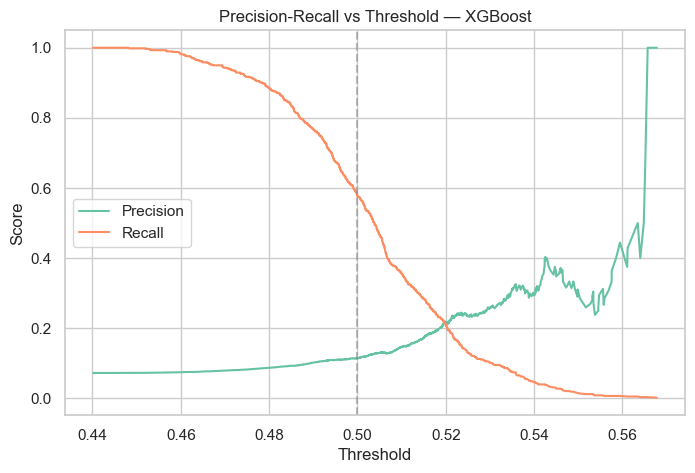

In [99]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_probs = xgb_tuned.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold — XGBoost')
plt.legend()
plt.axvline(0.5, color='gray', ls='--', alpha=0.5, label='Default (0.5)')
plt.show()

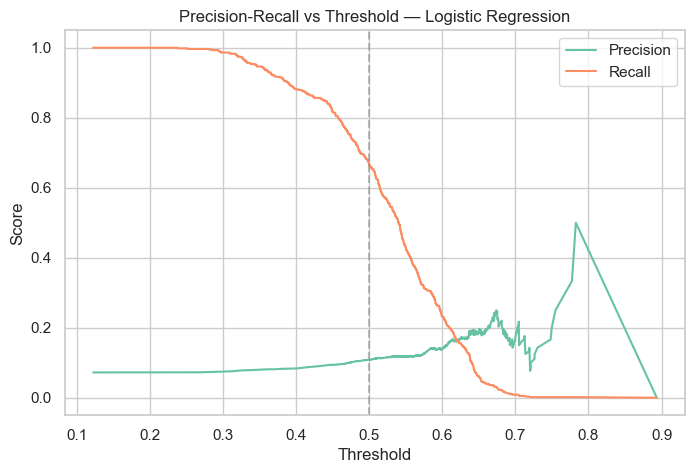

In [100]:
y_probs_lr = lr_tuned.predict_proba(X_test)[:, 1]

precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_probs_lr)

plt.figure(figsize=(8, 5))
plt.plot(thresholds_lr, precision_lr[:-1], label='Precision')
plt.plot(thresholds_lr, recall_lr[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold — Logistic Regression')
plt.legend()
plt.axvline(0.5, color='gray', ls='--', alpha=0.5, label='Default (0.5)')
plt.show()

## Random Under Sampler

Eliminates majority class

Oversampling is challenging with a dataset with a great discrepancy like this data set with majority "no"s

### Logistic Regression

In [101]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(y_train_rus.value_counts())

lr_rus = LogisticRegression(**best_lr, solver='liblinear', class_weight='balanced',
    max_iter=1000, random_state=42)
lr_rus.fit(X_train_rus, y_train_rus)
print(classification_report(y_test, lr_rus.predict(X_test), digits=3))

y
0    2317
1    2317
Name: count, dtype: int64
              precision    recall  f1-score   support

           0      0.956     0.596     0.734      7421
           1      0.111     0.646     0.189       579

    accuracy                          0.600      8000
   macro avg      0.533     0.621     0.462      8000
weighted avg      0.895     0.600     0.695      8000



### XGBoost

In [102]:
xgb_rus = XGBClassifier(**best_xgb, random_state=42)
xgb_rus.fit(X_train_rus, y_train_rus)
print(classification_report(y_test, xgb_rus.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.956     0.597     0.735      7421
           1      0.112     0.651     0.191       579

    accuracy                          0.601      8000
   macro avg      0.534     0.624     0.463      8000
weighted avg      0.895     0.601     0.696      8000



### Random Forest

In [103]:
rf_rus = RandomForestClassifier(**best_rf, random_state=42)
rf_rus.fit(X_train_rus, y_train_rus)
print(classification_report(y_test, rf_rus.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.958     0.588     0.728      7421
           1      0.112     0.667     0.192       579

    accuracy                          0.593      8000
   macro avg      0.535     0.627     0.460      8000
weighted avg      0.896     0.593     0.689      8000



## SMOTE TONEK

### Logistic Regression

In [104]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

print(y_train_smt.value_counts())

lr_smt = LogisticRegression(**best_lr, solver='liblinear', class_weight='balanced',
    max_iter=1000, random_state=42)
lr_smt.fit(X_train_smt, y_train_smt)
print(classification_report(y_test, lr_smt.predict(X_test), digits=3))

y
0    28726
1    28726
Name: count, dtype: int64
              precision    recall  f1-score   support

           0      0.950     0.635     0.761      7421
           1      0.108     0.568     0.182       579

    accuracy                          0.630      8000
   macro avg      0.529     0.602     0.472      8000
weighted avg      0.889     0.630     0.719      8000



### XGBoost

In [105]:
xgb_smt = XGBClassifier(**best_xgb, random_state=42)
xgb_smt.fit(X_train_smt, y_train_smt)
print(classification_report(y_test, xgb_smt.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.947     0.658     0.777      7421
           1      0.108     0.530     0.179       579

    accuracy                          0.649      8000
   macro avg      0.528     0.594     0.478      8000
weighted avg      0.887     0.649     0.733      8000



### Random Forest

In [106]:
rf_smt = RandomForestClassifier(**best_rf, random_state=42)
rf_smt.fit(X_train_smt, y_train_smt)
print(classification_report(y_test, rf_smt.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.946     0.715     0.815      7421
           1      0.116     0.477     0.186       579

    accuracy                          0.698      8000
   macro avg      0.531     0.596     0.500      8000
weighted avg      0.886     0.698     0.769      8000



## SMOTE ENN

Elminate certain majority class examples, and increases the minority class in a neighborhoud based approach

### Logistic Regression

In [107]:
from imblearn.combine import SMOTEENN

sme = SMOTEENN(random_state=42)
X_train_sme, y_train_sme = sme.fit_resample(X_train, y_train)

print(y_train_sme.value_counts())

lr_sme = LogisticRegression(**best_lr, solver='liblinear', class_weight='balanced',
    max_iter=1000, random_state=42)
lr_sme.fit(X_train_sme, y_train_sme)
print(classification_report(y_test, lr_sme.predict(X_test), digits=3))

y
1    22777
0    20810
Name: count, dtype: int64
              precision    recall  f1-score   support

           0      0.951     0.623     0.753      7421
           1      0.109     0.592     0.185       579

    accuracy                          0.621      8000
   macro avg      0.530     0.608     0.469      8000
weighted avg      0.891     0.621     0.712      8000



### XGBoost

In [108]:
xgb_sme = XGBClassifier(**best_xgb, random_state=42)
xgb_sme.fit(X_train_sme, y_train_sme)
print(classification_report(y_test, xgb_sme.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.959     0.493     0.651      7421
           1      0.101     0.727     0.177       579

    accuracy                          0.510      8000
   macro avg      0.530     0.610     0.414      8000
weighted avg      0.896     0.510     0.617      8000



### Random Forest

In [109]:
rf_sme = RandomForestClassifier(**best_rf, random_state=42)
rf_sme.fit(X_train_sme, y_train_sme)
print(classification_report(y_test, rf_sme.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.948     0.701     0.806      7421
           1      0.116     0.504     0.189       579

    accuracy                          0.686      8000
   macro avg      0.532     0.602     0.497      8000
weighted avg      0.888     0.686     0.761      8000



In [110]:
models["Logistic Regression Optimized"] = lr_sme
models["XGBoost Optimized"] = xgb_sme

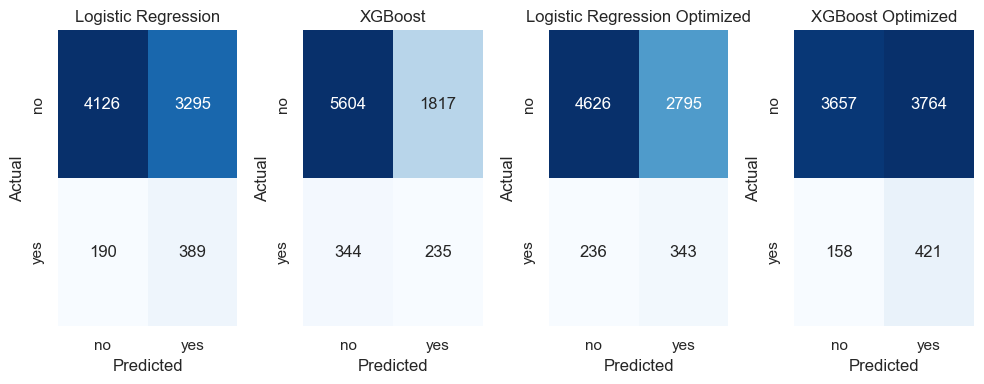

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(10, 4))

for ax, name in zip(axes, ['Logistic Regression', 'XGBoost', 'Logistic Regression Optimized', 'XGBoost Optimized']):
    cm = confusion_matrix(y_test, models[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['no', 'yes'], yticklabels=['no', 'yes'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [112]:
# --- Time-saved / targeting tradeoff (XGBoost Optimized) ---
avg_duration = df['duration'].mean()      
avg_campaign = df['campaign'].mean()      
contact_time_per_person = avg_duration * avg_campaign

# predicted-no column = people you skip calling
cm = confusion_matrix(y_test, models['XGBoost Optimized'].predict(X_test))
TN, FP, FN, TP = cm.ravel()
skipped = TN + FN                         # 3657 + 158

seconds_saved = contact_time_per_person * skipped
hours_saved   = seconds_saved / 3600
workdays      = hours_saved / 8

total       = TN + FP + FN + TP
skip_share  = skipped / total
recall      = TP / (TP + FN)              # subscribers kept
skip_rate   = FN / skipped                # subscription rate in skipped group
base_rate   = (TP + FN) / total

print(f"contact time/person : {contact_time_per_person:.1f} sec")
print(f"skipped (pred-no)   : {skipped}")
print(f"hours saved         : {hours_saved:,.1f}  ({workdays:,.1f} workdays)")
print(f"call volume cut     : {skip_share:.1%}")
print(f"subscribers kept    : {recall:.1%}")
print(f"skip-group sub rate : {skip_rate:.2%} vs base {base_rate:.2%}")
print(f"subscribers missed  : {FN} of {TP+FN} ({FN/(TP+FN):.1%})")

contact time/person : 734.4 sec
skipped (pred-no)   : 3815
hours saved         : 778.3  (97.3 workdays)
call volume cut     : 47.7%
subscribers kept    : 72.7%
skip-group sub rate : 4.14% vs base 7.24%
subscribers missed  : 158 of 579 (27.3%)


# Second Layer -

In [113]:
X_full = df_encoded.drop(columns=['y'])
y_full = df_encoded['y']
idx = X_test.index[models['XGBoost Optimized'].predict(X_test) == 1]
Xc, yc = X_full.loc[idx], y_full.loc[idx]
spw = (y_train == 0).sum() / (y_train == 1).sum()

models2 = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest':        RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost':              XGBClassifier(scale_pos_weight=spw, random_state=42),
}
for name, m in models2.items():
    m.fit(X_full.loc[X_train.index], y_train)
    print(f'--- {name} ---')
    print(classification_report(yc, m.predict(Xc)))

c:\Users\awvnn\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      3764
           1       0.33      0.86      0.48       421

    accuracy                           0.81      4185
   macro avg       0.66      0.83      0.68      4185
weighted avg       0.92      0.81      0.84      4185

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      3764
           1       0.69      0.23      0.35       421

    accuracy                           0.91      4185
   macro avg       0.81      0.61      0.65      4185
weighted avg       0.90      0.91      0.89      4185

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      3764
           1       0.45      0.81      0.58       421

    accuracy                           0.88      4185
   macro avg       0.72      0.85      0.76      4185
weighted

c:\Users\awvnn\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


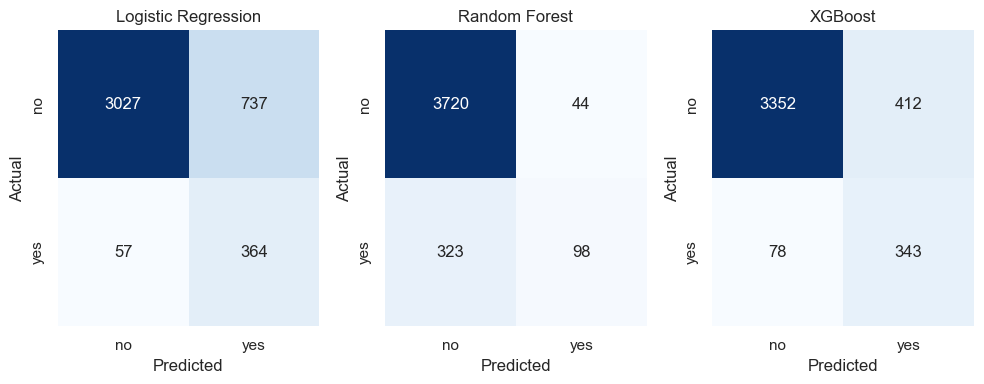

In [114]:
X_full = df_encoded.drop(columns=['y'])
y_full = df_encoded['y']
idx = X_test.index[models['XGBoost Optimized'].predict(X_test) == 1]
Xc, yc = X_full.loc[idx], y_full.loc[idx]
spw = (y_train == 0).sum() / (y_train == 1).sum()

models2 = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest':        RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost':              XGBClassifier(scale_pos_weight=spw, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, (name, m) in zip(axes, models2.items()):
    m.fit(X_full.loc[X_train.index], y_train)
    cm = confusion_matrix(yc, m.predict(Xc))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['no', 'yes'], yticklabels=['no', 'yes'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [115]:
# ===================== BUSINESS IMPACT: 2-LAYER CALL TARGETING =====================

X_full = df_encoded.drop(columns=['y'])
y_full = df_encoded['y']
avg_call_sec = df_encoded['duration'].mean()          # seconds per call

# ---- LAYER 1: skip the people predicted "no" ----
pred1 = models['XGBoost Optimized'].predict(X_test)
TN, FP, FN, TP = confusion_matrix(y_test, pred1).ravel()
skipped  = TN + FN
l1_hours = skipped * avg_call_sec * df_encoded['campaign'].mean() / 3600
print("LAYER 1  — skip who won't subscribe")
print(f"  calls skipped    : {skipped:,} of {len(y_test):,}  ({skipped/len(y_test):.0%})")
print(f"  subscribers kept : {TP/(TP+FN):.0%}")
print(f"  time saved       : ~{l1_hours:,.0f} agent-hours\n")

# ---- LAYER 2: rank the "call" group, dial highest-probability first ----
idx = X_test.index[pred1 == 1]
Xc, yc = X_full.loc[idx], y_full.loc[idx]
spw  = (y_train == 0).sum() / (y_train == 1).sum()
xgb2 = XGBClassifier(scale_pos_weight=spw, random_state=42).fit(X_full.loc[X_train.index], y_train)

ranked = (pd.DataFrame({'prob': xgb2.predict_proba(Xc)[:, 1], 'actual': yc.values})
          .sort_values('prob', ascending=False).reset_index(drop=True))
pool = len(ranked)
subs = int(ranked['actual'].sum())
cum  = ranked['actual'].cumsum()

print(f"LAYER 2  — call back the best leads first ({pool:,} people, {subs} subscribers)")
print(f"  {'want to catch':>14} | {'calls to make':>14} | {'time saved':>10}")
for catch in [0.80, 0.90, 1.00]:
    k   = int((cum >= np.ceil(subs * catch)).idxmax()) + 1     # calls needed
    hrs = (pool - k) * avg_call_sec / 3600
    print(f"  {catch:>13.0%} | {k:>6,} ({k/pool:>3.0%}) | ~{hrs:>6,.0f}h")

# headline uses the 90% row
k90 = int((cum >= np.ceil(subs * 0.90)).idxmax()) + 1
l2_hours = (pool - k90) * avg_call_sec / 3600
print(f"\nCOMBINED: ~{l1_hours + l2_hours:,.0f} agent-hours saved end to end, most conversions kept")

LAYER 1  — skip who won't subscribe
  calls skipped    : 3,815 of 8,000  (48%)
  subscribers kept : 73%
  time saved       : ~778 agent-hours

LAYER 2  — call back the best leads first (4,185 people, 421 subscribers)
   want to catch |  calls to make | time saved
            80% |    735 (18%) | ~   244h
            90% |  1,060 (25%) | ~   221h
           100% |  3,184 (76%) | ~    71h

COMBINED: ~1,000 agent-hours saved end to end, most conversions kept


# Unsupervised Learning

## K-Means for Second Layer Output

In [116]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import duckdb

con = duckdb.connect()

df = con.sql("""
    SELECT *,
    CASE WHEN y = 'yes' THEN 1 ELSE 0 END AS sub
    FROM df
""").df()
feats = ['age', 'balance', 'duration', 'campaign', 'education', 'housing', 'loan']

callback_idx = X_test.index[models['XGBoost Optimized'].predict(X_test) == 1]

# pick k: watch silhouette, higher = cleaner separation
Xs = StandardScaler().fit_transform(df_encoded.loc[callback_idx, feats])
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    print(f"k={k}  silhouette={silhouette_score(Xs, km.labels_):.3f}")

# profile at chosen k
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
g = df.loc[callback_idx].copy(); g['cluster'] = km.labels_
prof = g.groupby('cluster').agg(
    size=('sub', 'size'), sub_rate=('sub', 'mean'),
    age=('age', 'mean'), balance=('balance', 'mean'),
    duration=('duration', 'mean'), campaign=('campaign', 'mean')
).sort_values('sub_rate', ascending=False)
print(prof.round(2))

k=2  silhouette=0.211


k=3  silhouette=0.249
k=4  silhouette=0.258
k=5  silhouette=0.272
k=6  silhouette=0.258
         size  sub_rate     age    balance  duration  campaign
cluster                                                       
0         132    0.1400 46.6200 14423.5900  252.4400    2.6100
1        1817    0.1200 41.5100  1205.0100  257.7200    3.2900
2        1979    0.0800 38.0100  1106.1800  279.6600    2.5000
3         257    0.0800 37.8200   604.9700  267.0200    2.5900


Silhouette peaks around 0.27 and sits near 0.25 at k=4. That's weak separation, so treat these as a soft prioritization gradient, not four clean customer types. The split is driven almost entirely by balance, with age as a secondary axis. Duration and campaign barely move across clusters, so they aren't distinguishing anything here.

Cluster 0 (n=132, ~3% of callbacks, 14% subscribe, avg balance ~14.4k): a tiny high-balance segment with the best conversion, roughly double the low-balance clusters. Real-world value: this is your priority-call list. Small enough to hand to senior agents for a personal call, and the payoff per contact is highest.

Cluster 1 (n=1,817, 12% subscribe, mid balance ~1.2k, older ~42): the largest genuinely productive block. Standard-effort calls, good volume, decent hit rate. This is where most actual subscriptions will come from in absolute terms.

Cluster 2 (n=1,979, 8% subscribe, mid balance ~1.1k, younger ~38): similar balance to cluster 1 but younger and converts a third less. Same-ish financial profile, worse response, so age is doing real work here. Lower priority than cluster 1.

Cluster 3 (n=257, 8% subscribe, low balance ~600, youngest): small, low-balance, low-conversion. Cheapest to deprioritize if call capacity is tight.

Business takeaway: balance is the lever. Call order should be cluster 0 → 1 → 2 → 3. The honest caveat for the writeup: the low silhouette means these groups overlap heavily, so the value is in coarse triage of an already-filtered list, not in claiming distinct personas. If you want sharper segments, the k=5 run scored slightly higher, but check whether the extra cluster is interpretable before using it.

### K-Means for Categorical

In [117]:
num_feats = ['age', 'balance', 'duration', 'campaign']
cat_feats = [c for c in df_encoded.columns
             if c.startswith(('job_', 'marital_', 'contact_'))] \
            + ['education', 'housing', 'loan']
feats = num_feats + cat_feats

Xs = StandardScaler().fit_transform(df_encoded.loc[callback_idx, feats])
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    print(f"k={k}  silhouette={silhouette_score(Xs, km.labels_):.3f}")

k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
g = df.loc[callback_idx].copy(); g['cluster'] = km.labels_

print(prof_full.to_string())

k=2  silhouette=0.114
k=3  silhouette=0.127
k=4  silhouette=0.123
k=5  silhouette=0.140
k=6  silhouette=0.140
         size  sub_rate     age    balance  duration  campaign                job        marital        education    default     housing        loan         contact
cluster                                                                                                                                                             
0         132    0.1364 46.6212 14423.5909  252.4394    2.6136   management (39%)  married (69%)   tertiary (50%)  no (100%)    no (63%)   no (100%)  cellular (83%)
1        1817    0.1211 41.5146  1205.0072  257.7232    3.2917   management (27%)  married (54%)  secondary (44%)   no (99%)   no (100%)   no (100%)  cellular (88%)
2        1979    0.0824 38.0076  1106.1844  279.6589    2.4997  blue-collar (25%)  married (48%)  secondary (57%)   no (99%)  yes (100%)   no (100%)  cellular (91%)
3         257    0.0778 37.8171   604.9728  267.0195    2.5914  b

Numeric split is still driven by balance and age. The categorical modes now show who each cluster is, and two of them (housing, loan) turn out to be near-100% within a cluster, meaning k-means basically carved the groups along those binary flags. That's the real story here.

Cluster 0 (n=132, 14% subscribe): affluent, established. Management, married, tertiary-educated, high balance (~14k), no housing loan, no personal loan. Best conversion. Your premium call list, these are financially secure people with cash to park in a term deposit.

Cluster 1 (n=1,817, 12% subscribe): mainstream professionals. Management-leaning, married, mid balance, no loans of either kind. Largest productive block, standard-effort calls, most absolute subscriptions come from here.

Cluster 2 (n=1,979, 8% subscribe): homeowners with a mortgage. Blue-collar, married, and 100% carry a housing loan. Conversion drops by a third versus cluster 1 despite similar balance. Real-world read: mortgage servicing eats disposable cash, so less appetite for locking money in a deposit. Lower priority.

Cluster 3 (n=257, 8% subscribe): personal-loan holders. Blue-collar, single, lower balance, 100% carry a personal loan. Lowest conversion. Existing debt plus thin balances, weakest prospects, deprioritize when capacity is tight.

Business takeaway: the loan flags are the actionable signal the numeric-only view hid. Debt-free clusters (0, 1) convert ~12-14%; loan-burdened clusters (2, 3) convert ~8%. Call order stays 0 → 1 → 2 → 3, but now you can justify it: target debt-free, higher-balance customers first, since existing loan obligations predict lower deposit uptake.

## K-Means for Total Data Set

In [118]:
Xs_all = StandardScaler().fit_transform(df_encoded[feats])
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs_all)
    print(f"k={k}  silhouette={silhouette_score(Xs_all, km.labels_):.3f}")

k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs_all)
g = df.copy(); g['cluster'] = km.labels_
prof = g.groupby('cluster').agg(
    size=('sub', 'size'), sub_rate=('sub', 'mean'),
    age=('age', 'mean'), balance=('balance', 'mean'),
    duration=('duration', 'mean'), campaign=('campaign', 'mean')
).sort_values('sub_rate', ascending=False)
print(prof.round(2))

k=2  silhouette=0.113
k=3  silhouette=0.133
k=4  silhouette=0.093
k=5  silhouette=0.120
k=6  silhouette=0.169
          size  sub_rate     age   balance  duration  campaign
cluster                                                       
1         1437    0.1100 57.1900 1513.7100  257.0800    2.6500
0        11051    0.1000 33.9100 1229.4300  269.4600    2.7900
2        27512    0.0600 42.3400 1279.7900  248.8300    2.9300


Full-dataset clusters (40,000 customers, k=3, silhouette ~0.13)

Unlike the second-layer version, this is run on everyone, not the model-flagged callbacks. The split here is driven almost entirely by age. Balance, duration, and campaign are nearly flat across all three clusters, so they aren't separating anyone. This is basically an age segmentation.

Cluster 1 (n=1,437, 11% subscribe, avg age ~57): older customers. Smallest group, highest conversion. Real-world read: near or in retirement, term deposits fit their low-risk, capital-preservation mindset. High-value despite low volume.

Cluster 0 (n=11,051, 10% subscribe, avg age ~34): younger customers. Second-best conversion and a large group, so a meaningful source of absolute subscriptions.

Cluster 2 (n=27,512, 6% subscribe, avg age ~42): the mid-age bulk of the base, ~69% of everyone. Lowest conversion. This is the mass-market segment where blanket calling wastes the most effort.

Business takeaway: age brackets the response. The two smaller, age-extreme groups (older ~11%, younger ~10%) convert nearly twice as well as the dominant middle-aged block (~6%). The practical value: don't call the base uniformly. Prioritize the young and near-retirement segments, and treat the large middle cluster as low-yield, exactly the majority you want your first-layer model to filter out before anyone dials.

## Dimensionality Reduction

### TSNE

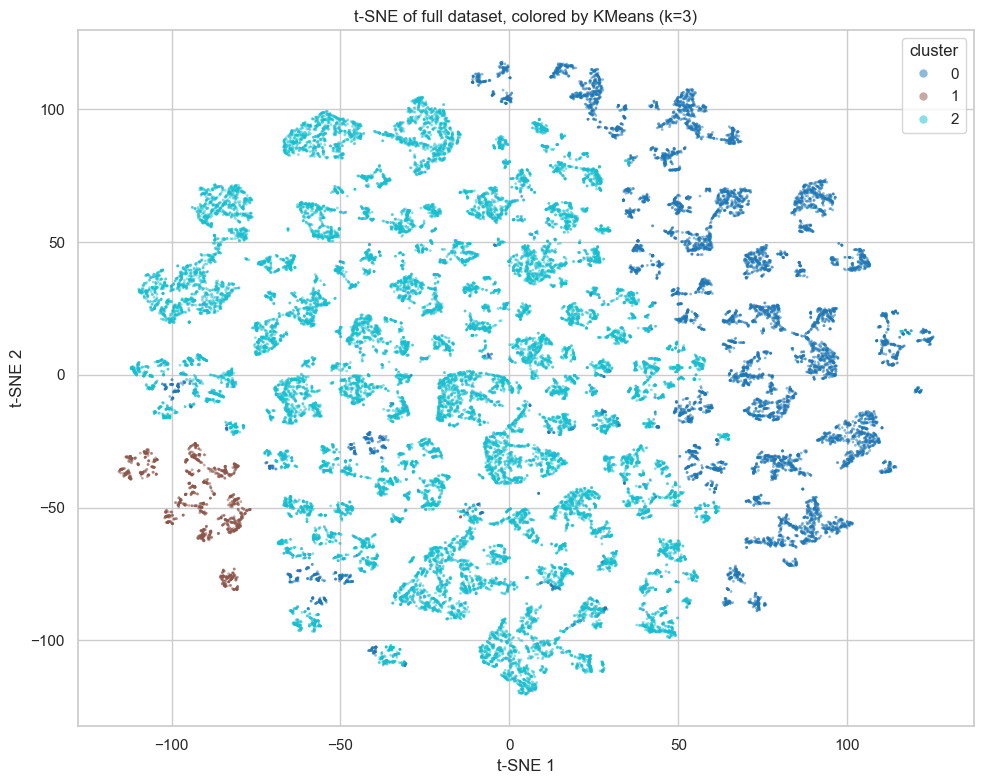

In [119]:
from sklearn.manifold import TSNE

# cluster the full 40k on the same matrix we embed (refit here so it doesn't
# depend on which km happens to be in memory)
k = 3
labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Xs_all)

tsne = TSNE(
    n_components=2,
    perplexity=40,          # 30-50 is sane for 40k
    init='pca',
    learning_rate='auto',
    random_state=42,
    n_jobs=-1,
)
emb = tsne.fit_transform(Xs_all)   # ~1-3 min on 40k

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    emb[:, 0], emb[:, 1],
    c=labels, cmap='tab10',
    s=4, alpha=0.5, linewidths=0,
)
plt.legend(*sc.legend_elements(), title='cluster', loc='best')
plt.title(f't-SNE of full dataset, colored by KMeans (k={k})')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout(); plt.show()

t-SNE of the full 40k, colored by KMeans (k=3)

The plot validates the clustering better than the silhouette score implied. Two things stand out:

The k-means clusters mostly agree with t-SNE's geometry. Cluster 0 (blue) owns the right side, cluster 2 (cyan) owns the left/center, and cluster 1 (brown) sits as a tight, isolated island bottom-left. That brown group is the one genuinely clean separation, small, dense, well-detached from everything else, which matches it being the ~1,437 older/high-conversion cluster. It's a real segment, not an artifact.

Blue and cyan share a soft, gradient-like border rather than a hard gap. Along the center there's visible color-mixing where the two bleed into each other. That's the low silhouette showing up visually: k-means drew a boundary through what is really a continuum (the age gradient), so points near the seam could go either way. Consistent with cluster 2 being the low-yield mass-market bulk that shades into cluster 0.

The many small sub-blobs are t-SNE picking up local micro-structure (shared categorical combos, one-hot groupings), not additional clusters. Don't over-read them, t-SNE manufactures those clumps from the neighbor graph.

Takeaway: k=3 is defensible. One clearly distinct segment (brown) plus two large groups split along a genuine but fuzzy gradient. The visual honesty for your writeup: the separation is real enough to act on for targeting, but it's a gradient, not three crisp personas, so keep the language as "response tiers," not "distinct customer types."

### PCA

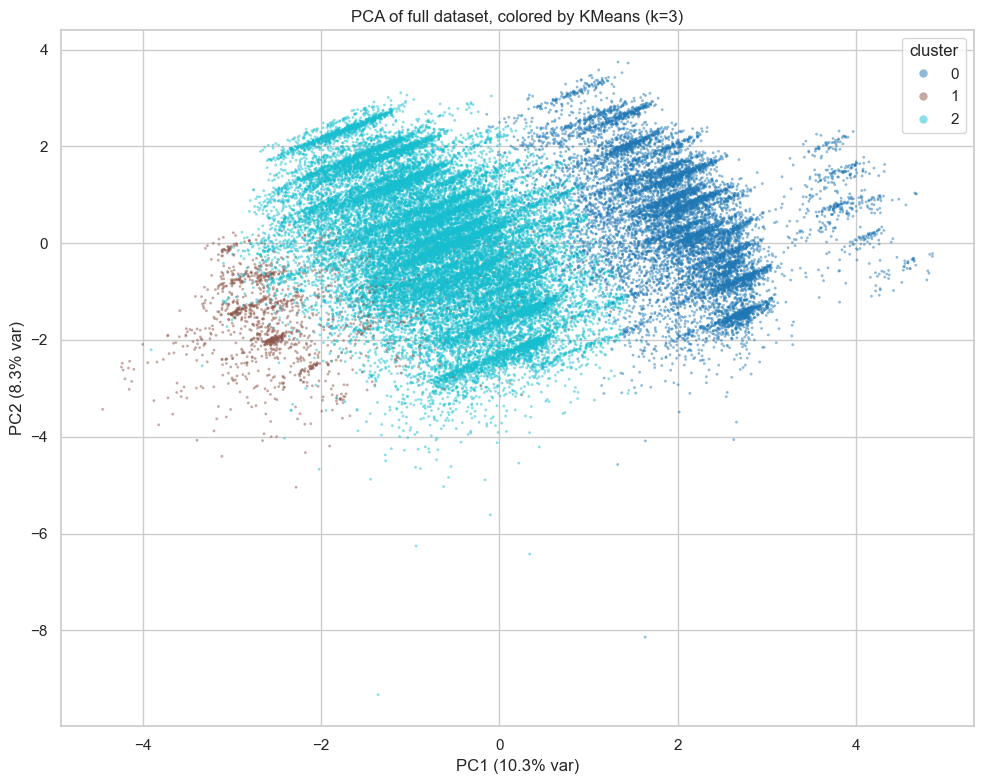

PC1+PC2 capture 18.6% of variance


In [120]:
from sklearn.decomposition import PCA

k = 3
labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Xs_all)

pca = PCA(n_components=2, random_state=42)
emb = pca.fit_transform(Xs_all)
evr = pca.explained_variance_ratio_

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    emb[:, 0], emb[:, 1],
    c=labels, cmap='tab10',
    s=4, alpha=0.5, linewidths=0,
)
plt.legend(*sc.legend_elements(), title='cluster', loc='best')
plt.title(f'PCA of full dataset, colored by KMeans (k={k})')
plt.xlabel(f'PC1 ({evr[0]:.1%} var)'); plt.ylabel(f'PC2 ({evr[1]:.1%} var)')
plt.tight_layout(); plt.show()

print(f"PC1+PC2 capture {evr.sum():.1%} of variance")

PCA confirms the cluster ordering but is the weakest of the three views, exactly as predicted. Low explained variance plus one-hot striping means the 2D projection loses most of the signal. t-SNE and UMAP handle this data better because they're nonlinear and neighbor-based. Use PCA here to show you tried the standard linear baseline and to demonstrate you understand why it's weak, not as your primary cluster visualization.

### U-Map

c:\Users\awvnn\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


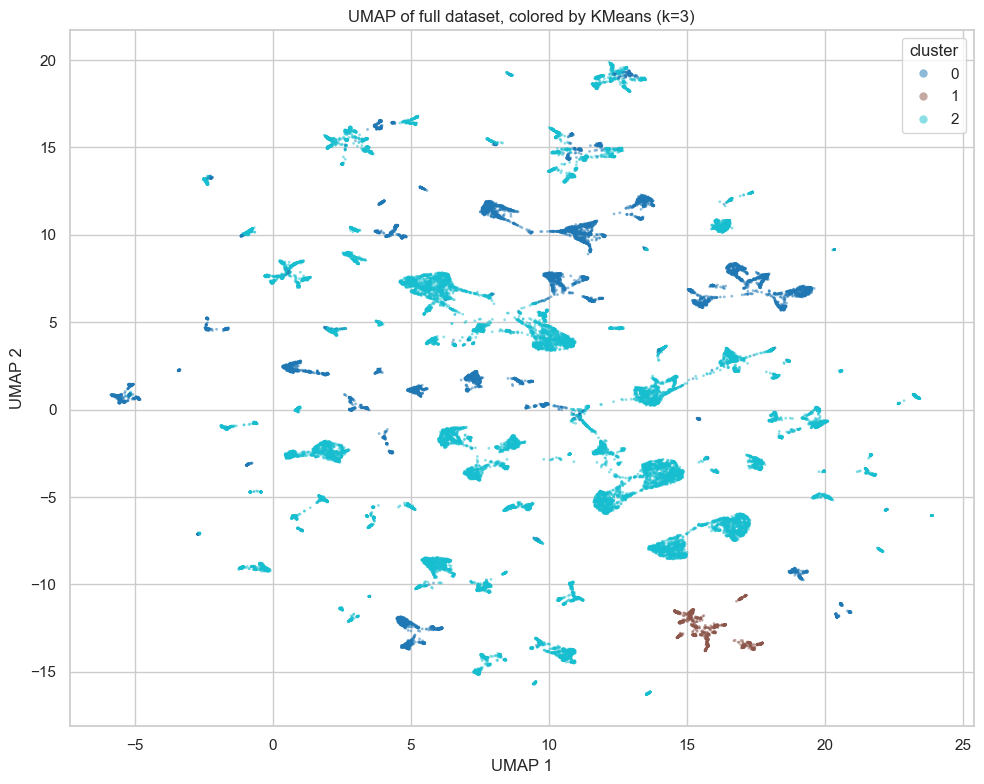

In [121]:
import umap

k = 3
labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Xs_all)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,      # higher = more global structure, less local detail
    min_dist=0.1,        # lower = tighter clumps
    random_state=42,
)
emb = reducer.fit_transform(Xs_all)

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    emb[:, 0], emb[:, 1],
    c=labels, cmap='tab10',
    s=4, alpha=0.5, linewidths=0,
)
plt.legend(*sc.legend_elements(), title='cluster', loc='best')
plt.title(f'UMAP of full dataset, colored by KMeans (k={k})')
plt.xlabel('UMAP 1'); plt.ylabel('UMAP 2')
plt.tight_layout(); plt.show()

UMAP shatters the data into many small, tight islands. This is the nonlinear method aggressively surfacing local structure, mostly shared categorical combinations (job × education × loan × housing patterns from the one-hot features). Those micro-clusters are real groupings in feature space, but they are not the k=3 clusters, so don't count blobs.

What matters is the coloring within and across islands:

Cluster 1 (brown) again lands as one compact, isolated island bottom-right. Third view in a row where this group cleanly detaches, so the older/high-conversion segment is genuinely distinct, not a k-means accident. That's your most defensible, most actionable segment.

Clusters 0 (blue) and 2 (cyan) don't own clean regions. They're scattered across the whole map, and crucially, many individual islands contain both colors mixed together. That mixing is the tell: k-means is slicing a boundary through groups that UMAP considers single neighborhoods. Same continuum problem as t-SNE and PCA, just more visible here because UMAP draws the local groups sharply.

# Summary



## Problem
European bank runs a call-center campaign selling term deposits. Only ~7% of contacted customers subscribe, so blanket calling wastes most agent time. Goal: raise call success rate while keeping the model interpretable enough for the client to act on.

## Data
40,000 call records. Numeric (age, balance, duration, campaign) plus categoricals (job, marital, education, default, housing, loan, contact, month). Target `y` is heavily imbalanced, ~93% no / ~7% yes.

## Approach: two-layer targeting

**Layer 1, filter.** XGBoost drops customers predicted not to subscribe so agents never dial them. Optimized for recall on the yes class, we accept false positives to avoid missing real subscribers. Imbalance handled via resampling (RandomUnderSampler, SMOTETomek, SMOTEENN tested) and `scale_pos_weight`, tuned with Hyperopt against Logistic Regression and Random Forest baselines.
- Calls skipped: 3,815 of 8,000 (48%)
- Subscribers retained: 73%
- Agent-hours saved: ~778

**Layer 2, rank.** Within the 4,185 the filter says "call," a second XGBoost ranks by subscription probability so agents dial the best leads first. Turns a yes/no filter into a priority queue.
- Catch 80% of subscribers: call 735 (18% of the pool)
- Catch 90%: call 1,060 (25%)
- Catch 100%: call 3,184 (76%)

**Combined: ~1,000 agent-hours saved end to end while keeping most conversions.** Instead of calling everyone at a ~7% hit rate, effort concentrates on a smaller, higher-yield list.

## Unsupervised segmentation

Ran KMeans on the full 40k and on the Layer-1 callback group, then profiled clusters. Since categoricals can't be averaged, profiles use numeric means plus the mode (most frequent category) per feature.

**Callback clusters (4,185 flagged, k=4).** The actionable signal was loan status, which the numeric-only view hid:
- Debt-free, higher-balance customers convert ~12-14%.
- Customers carrying a housing or personal loan convert ~8%.

Read: existing debt predicts lower deposit uptake. Call order: high-balance debt-free first.

**Full dataset (k=3).** Splits mainly on age. Older (~57) and younger (~34) segments convert ~10-11%; the mid-age bulk (~69% of the base) converts ~6%. Confirms most of the population is low-yield, exactly what Layer 1 filters.

## Visualization (t-SNE, PCA, UMAP)

All three projections tell the same story, which is what makes it credible:

| view | cluster 1 (older, high-conversion) | clusters 0 vs 2 |
|---|---|---|
| t-SNE | clean, isolated island | soft gradient |
| PCA | separated on PC1 (only ~19% variance) | smeared |
| UMAP | clean, isolated island | mixed within blobs |

One genuinely distinct, high-value segment plus two large groups split along a fuzzy age/response gradient. PCA underperformed as expected: linear method on a mostly one-hot feature space, low explained variance, visible striping artifacts.

## Honest limitations
- Cluster silhouettes are low (~0.13 full set, ~0.25 callbacks). These are response tiers along a continuum, not distinct personas. The exception is the older high-conversion segment, which separates cleanly in every view.
- KMeans on mixed one-hot + numeric features with Euclidean distance is theoretically weak. k-prototypes is the correct method if sharper mixed-type segments are needed.
- `duration` is known only after a call ends, so it leaks and cannot be used for pre-call targeting in production. Must be removed before deployment, and note the time-saved figures lean on it.

## Business takeaway
Don't call the base uniformly. Filter out the low-yield majority (Layer 1), rank the remainder (Layer 2), prioritize debt-free, higher-balance, age-extreme customers. The design delivers both the ~1,000-hour efficiency lift and the interpretability the client asked for.